# 03 — Первый воспроизводимый baseline

Этот notebook строит **честную точку отсчёта** для обычной табличной классификации или регрессии. Он сравнивает no-skill модель и простую модель на одних folds, при этом imputation, scaling и encoding обучаются только внутри train-части каждого fold.

Notebook остаётся оркестратором: конфигурация хранится отдельно, а переиспользуемая логика импортируется из `src/ml_project/modeling/`.

| Что настраивается | Единый источник истины |
|---|---|
| Файлы, target, key, группы признаков | `src/ml_project/config.py` |
| Контракт основной метрики | `docs/00_problem.md` → `(primary_metric:: ...)` |
| CV, preprocessing, модель и действия записи | `src/ml_project/baseline_config.py` |
| Обоснование validation-протокола | `docs/03_validation.md` |
| Решения о составе признаков | `docs/04_features.md` |

<details>
<summary><strong>Критические предостережения — прочитать перед запуском</strong></summary>

1. **Не заполняйте пропуски до CV.** Медиана, среднее, scaling, encoding и feature selection должны обучаться внутри `Pipeline` на train-fold.
2. **Inference/test не является validation.** Этот notebook не оценивает качество по inference-датасету и не использует его статистики.
3. **Схема split важнее модели.** Для времени, пользователей, устройств, пациентов и повторных объектов обычный random split может давать ложный результат.
4. **Identifier не становится признаком автоматически.** KEY, target и группы `identifier`/`ignored` исключаются из model matrix.
5. **Baseline — не попытка получить лучший score.** Это простая, воспроизводимая нижняя точка сравнения.
6. **Не включайте несколько изменений одновременно.** После baseline каждую существенную идею проверяйте отдельным экспериментом.
7. **Loss-метрики sklearn имеют префикс `neg_`.** В отчёте знак возвращается к обычному виду, а направление показывается как `minimize`.
8. **Запись управляется явно.** Модель, CSV и Markdown изменяются только полями `save_*` / `sync_*` объекта `baseline_config.BASELINE`.

</details>

> [!note]
> Для текста, изображений, временных рядов и deep learning этот notebook служит архитектурным каркасом. Добавляется новый transformer/estimator, но границы `config → pipeline → CV → artifacts → docs` сохраняются.


## 0. Перед первым запуском

- [ ] В `docs/00_problem.md` заполнено `(primary_metric:: ...)`.
- [ ] В `src/ml_project/config.py` заданы `TARGET`, `KEY` и все `FEATURE_GROUPS`.
- [ ] В `docs/03_validation.md` обоснована схема split.
- [ ] В объекте `BASELINE` файла `src/ml_project/baseline_config.py` заполнено поле `task_type`.
- [ ] Установлены зависимости: из корня проекта `python -m pip install -r requirements.txt`, либо из notebook `%pip install -r ../requirements.txt`.

Сначала исправьте конфиги, затем запускайте notebook сверху вниз.


In [3]:
from pathlib import Path
import importlib
import sys

from IPython.display import display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").exists() and (candidate / "src").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.baseline_config as baseline_config
import ml_project.modeling as modeling_tools

print(f"Корень проекта: {PROJECT_ROOT}")


Корень проекта: D:\Projects\Titanik-ML-project


## 1. Перечитать и проверить конфигурацию

После любого изменения `config.py` или `baseline_config.py` повторно запустите эту ячейку и все ячейки ниже. **Restart kernel не требуется.**


In [4]:
project_config = importlib.reload(project_config)
baseline_config = importlib.reload(baseline_config)
modeling_tools = importlib.reload(modeling_tools)

DATASETS = project_config.DATASETS
FEATURE_GROUPS = project_config.FEATURE_GROUPS
INFERENCE_DATASET = project_config.INFERENCE_DATASET
KEY = project_config.KEY
RAW_DIR = project_config.RAW_DIR
TARGET = project_config.TARGET
TRAIN_DATASET = project_config.TRAIN_DATASET

settings = baseline_config.BASELINE
display(modeling_tools.settings_report(settings))

config_warnings = modeling_tools.validate_modeling_settings(settings)
for warning in config_warnings:
    print(f"ПРЕДУПРЕЖДЕНИЕ: {warning}")
print("Конфигурация baseline прошла проверку.")


,section,parameter,value
0,task,task_type,binary_classification
1,features,model_feature_groups,"(numeric, count, categorical, ordinal)"
2,features,include_features,all
3,features,exclude_features,"(Cabin,)"
4,metric,primary_scorer,from 00_problem
5,metric,secondary_scorers,"{'Balanced accuracy': 'balanced_accuracy', 'Pr..."
6,validation,cv_strategy,stratified_kfold
7,validation,n_splits,5
8,validation,shuffle,True
9,validation,random_state,42


Конфигурация baseline прошла проверку.


## 2. Загрузить train и зафиксировать версию

Загружается исходный train из `data/raw`. Notebook не создаёт заранее «очищенный» общий CSV: model-ready преобразования должны оставаться внутри pipeline.


In [5]:
catalog = DataCatalog(PROJECT_ROOT, RAW_DIR, DATASETS)
catalog.validate()

available_datasets = set(catalog.available_names())
if TRAIN_DATASET not in available_datasets:
    raise KeyError(f"Train dataset {TRAIN_DATASET!r} is unavailable.")

train_frame = catalog.load(TRAIN_DATASET).copy()
inference_frame = (
    catalog.load(INFERENCE_DATASET).copy()
    if INFERENCE_DATASET and INFERENCE_DATASET in available_datasets
    else None
)

file_report = catalog.file_report()
train_file = file_report.loc[file_report["dataset"] == TRAIN_DATASET].iloc[0]
dataset_version = str(train_file["sha256"])

print(f"Train: {train_frame.shape[0]:,} строк × {train_frame.shape[1]:,} столбцов")
print(f"Версия train (SHA-256): {dataset_version}")
if inference_frame is not None:
    print(f"Inference: {inference_frame.shape[0]:,} строк × {inference_frame.shape[1]:,} столбцов")
else:
    print("Inference-датасет не настроен или отсутствует — для CV это не проблема.")


Train: 891 строк × 12 столбцов
Версия train (SHA-256): 7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f
Inference: 418 строк × 11 столбцов


## 3. Построить явный feature plan

Типы признаков берутся только из `FEATURE_GROUPS`, а не угадываются по dtype. Таблица ниже показывает каждый столбец и причину его использования или исключения.


In [6]:
feature_plan = modeling_tools.resolve_feature_plan(
    train_frame,
    FEATURE_GROUPS,
    target=TARGET,
    key=KEY,
    settings=settings,
)
display(feature_plan.to_frame())

for warning in feature_plan.warnings:
    print(f"ПРЕДУПРЕЖДЕНИЕ: {warning}")

if inference_frame is not None:
    inference_warnings = modeling_tools.validate_inference_schema(
        inference_frame,
        feature_plan,
        strict=settings.require_inference_features,
    )
    for warning in inference_warnings:
        print(f"ПРЕДУПРЕЖДЕНИЕ: {warning}")

prepared = modeling_tools.prepare_training_data(
    train_frame,
    target=TARGET,
    plan=feature_plan,
    settings=settings,
)
print("Model matrix:", prepared.X.shape)
print("Числовые признаки:", len(feature_plan.numeric))
print("Категориальные признаки:", len(feature_plan.categorical))
print("Исключённые признаки:", len(feature_plan.excluded))


,feature,config_group,model_role,status,reason
0,Age,numeric,numeric,used,
1,Fare,numeric,numeric,used,
2,SibSp,count,numeric,used,
3,Parch,count,numeric,used,
4,Sex,categorical,categorical,used,
5,Cabin,categorical,—,excluded,explicit BASELINE.exclude_features
6,Embarked,categorical,categorical,used,
7,Pclass,ordinal,categorical,used,
8,Name,text,—,excluded,group 'text' is not enabled for this baseline
9,PassengerId,identifier,—,excluded,project key / identifier


ПРЕДУПРЕЖДЕНИЕ: Текстовые и временные признаки намеренно исключены из первого табличного baseline: Name
Model matrix: (891, 7)
Числовые признаки: 4
Категориальные признаки: 3
Исключённые признаки: 4


## 4. Собрать preprocessing

`SimpleImputer`, scaler и `OneHotEncoder` пока **не обучаются**. Они становятся частью общего sklearn `Pipeline` и будут fit-иться заново внутри каждого train-fold.

`remainder="drop"` защищает от случайного попадания незаявленного столбца в модель.


In [7]:
preprocessor = modeling_tools.build_tabular_preprocessor(
    settings,
    feature_plan,
)
display(modeling_tools.preprocessing_report(settings, feature_plan))
print(preprocessor)


,model_role,features,imputation,representation,unknown_policy
0,numeric,4,median,standard,—
1,categorical,3,most_frequent,one-hot,ignore


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(keep_empty_features=True,
                                                                strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(keep_empty_features=True,
                                                                strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked'])])


## 5. Собрать metric и CV

Основная метрика читается из `docs/00_problem.md`. `PRIMARY_SCORER` в baseline-конфиге является только техническим адаптером на случай, если человеческое название не совпадает с именем scorer в sklearn.


In [11]:
scoring_plan = modeling_tools.resolve_scoring_plan(
    PROJECT_ROOT,
    settings,
)
cv, resolved_cv_strategy = modeling_tools.build_cv_splitter(
    settings,
    prepared.y,
)
cv_description = modeling_tools.cv_protocol_description(
    settings,
    resolved_cv_strategy,
)

display(scoring_plan.to_frame())
print("Validation:", cv_description)
if settings.cv_strategy == "auto":
    print("ПРЕДУПРЕЖДЕНИЕ: auto-стратегию нужно заменить явной после фиксации validation-протокола.")


,role,report_name,sklearn_scorer,direction
0,primary,accuracy,accuracy,maximize
1,secondary,Balanced accuracy,balanced_accuracy,maximize
2,secondary,Precision,precision,maximize
3,secondary,Recall,recall,maximize
4,secondary,F1,f1,maximize
5,secondary,ROC-AUC,roc_auc,maximize


Validation: stratified_kfold(n_splits=5, shuffle=True, seed=42)


## 6. Собрать сравнимые baseline-модели

Обе модели получают один и тот же preprocessing и один и тот же CV:

- `dummy` — no-skill нижняя граница;
- простая модель — логистическая регрессия для классификации или Ridge для регрессии; в отчёте используется её настоящее имя.

Более мощная sklearn-совместимая модель позднее может использовать тот же `preprocessor`, `build_model_pipeline` и `evaluate_models_cv`.


In [9]:
models = {}
if settings.run_dummy_baseline:
    models["dummy"] = modeling_tools.build_model_pipeline(
        preprocessor,
        modeling_tools.build_dummy_estimator(settings),
    )

simple_model_name = modeling_tools.resolved_model_name(settings)
models[simple_model_name] = modeling_tools.build_model_pipeline(
    preprocessor,
    modeling_tools.build_simple_estimator(settings),
)

print("Модели:", ", ".join(models))
print("Simple estimator:", simple_model_name)


Модели: dummy, logistic_regression
Simple estimator: logistic_regression


## 7. Выполнить cross-validation

Это единственная ячейка, где рассчитывается baseline-score. Если она падает, не заменяйте ошибку на `NaN`: исправьте feature schema, split, scorer или preprocessing.


In [12]:
evaluation = modeling_tools.evaluate_models_cv(
    models,
    prepared,
    cv=cv,
    scoring=scoring_plan,
    settings=settings,
)

validation_folds = evaluation.fold_scores[
    evaluation.fold_scores["split"] == "validation"
]
fold_table = validation_folds.pivot_table(
    index=["model", "fold"],
    columns="metric",
    values="value",
).reset_index()

display(fold_table.round(4))
display(evaluation.summary.round(4))


metric,model,fold,Balanced accuracy,F1,Precision,ROC-AUC,Recall,accuracy
0,dummy,1,0.5000,0.0000,0.0000,0.5000,0.0000,0.6145
1,dummy,2,0.5000,0.0000,0.0000,0.5000,0.0000,0.6180
2,dummy,3,0.5000,0.0000,0.0000,0.5000,0.0000,0.6180
3,dummy,4,0.5000,0.0000,0.0000,0.5000,0.0000,0.6180
4,dummy,5,0.5000,0.0000,0.0000,0.5000,0.0000,0.6124
5,logistic_regression,1,0.7687,0.7153,0.7206,0.8741,0.7101,0.7821
6,logistic_regression,2,0.7820,0.7287,0.7705,0.8501,0.6912,0.8034
7,logistic_regression,3,0.7662,0.7049,0.7963,0.8267,0.6324,0.7978
8,logistic_regression,4,0.7694,0.7153,0.7101,0.8267,0.7206,0.7809
9,logistic_regression,5,0.8080,0.7647,0.7761,0.8794,0.7536,0.8202


,model,split,metric_key,metric,direction,mean,std,min,max,folds,fit_seconds_mean,score_seconds_mean
0,dummy,validation,primary,accuracy,maximize,0.6162,0.0026,0.6124,0.6180,5,0.0396,0.0204
1,dummy,validation,secondary_1,Balanced accuracy,maximize,0.5000,0.0000,0.5000,0.5000,5,0.0396,0.0204
2,dummy,validation,secondary_2,Precision,maximize,0.0000,0.0000,0.0000,0.0000,5,0.0396,0.0204
3,dummy,validation,secondary_3,Recall,maximize,0.0000,0.0000,0.0000,0.0000,5,0.0396,0.0204
4,dummy,validation,secondary_4,F1,maximize,0.0000,0.0000,0.0000,0.0000,5,0.0396,0.0204
5,dummy,validation,secondary_5,ROC-AUC,maximize,0.5000,0.0000,0.5000,0.5000,5,0.0396,0.0204
6,logistic_regression,validation,primary,accuracy,maximize,0.7969,0.0163,0.7809,0.8202,5,0.0562,0.0196
7,logistic_regression,validation,secondary_1,Balanced accuracy,maximize,0.7788,0.0174,0.7662,0.8080,5,0.0562,0.0196
8,logistic_regression,validation,secondary_2,Precision,maximize,0.7547,0.0374,0.7101,0.7963,5,0.0562,0.0196
9,logistic_regression,validation,secondary_3,Recall,maximize,0.7016,0.0448,0.6324,0.7536,5,0.0562,0.0196


## 8. Интерпретировать результат до сохранения

Проверьте не только среднее:

1. Простая модель должна осмысленно сравниваться с `dummy`.
2. Большой `std` между folds означает нестабильность оценки или неоднородные данные.
3. Подозрительно высокий результат требует повторной проверки leakage.
4. Слабый результат не означает, что notebook сломан: baseline фиксирует реальную стартовую точку.
5. Нельзя утверждать, что отдельный preprocessing-шаг «помог», пока он не проверен контролируемым экспериментом.


In [13]:
primary_result = evaluation.primary_summary().copy()
primary_result["mean ± std"] = primary_result.apply(
    lambda row: f"{row['mean']:.4f} ± {row['std']:.4f}",
    axis=1,
)
display(
    primary_result[
        ["model", "metric", "direction", "mean ± std", "min", "max", "fit_seconds_mean"]
    ].round(4)
)


,model,metric,direction,mean ± std,min,max,fit_seconds_mean
0,dummy,accuracy,maximize,0.6162 ± 0.0026,0.6124,0.6180,0.0396
1,logistic_regression,accuracy,maximize,0.7969 ± 0.0163,0.7809,0.8202,0.0562


## 9. Просмотреть график каждой метрики

Для каждой основной и дополнительной метрики строится отдельный график значений на validation-folds. Линии показывают разброс между folds, а пунктир — среднее модели. Эти же Figure будут сохранены как PNG, если в `BASELINE` включены `save_artifacts` и `save_metric_figures`.


Метрика: accuracy


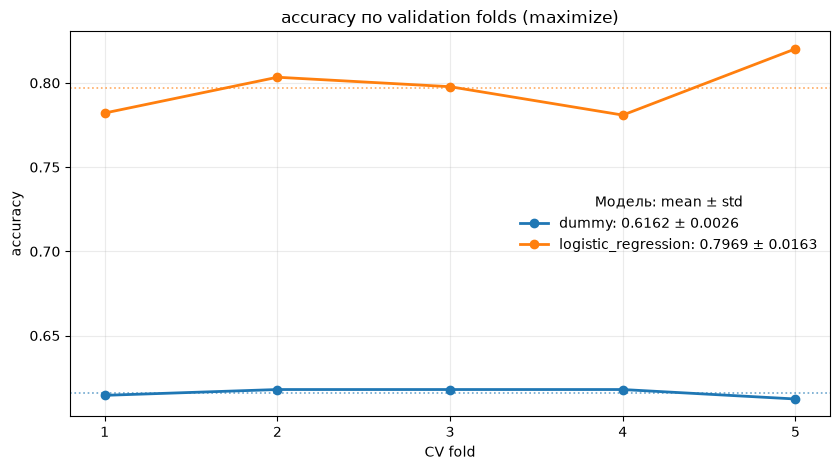

Метрика: Balanced accuracy


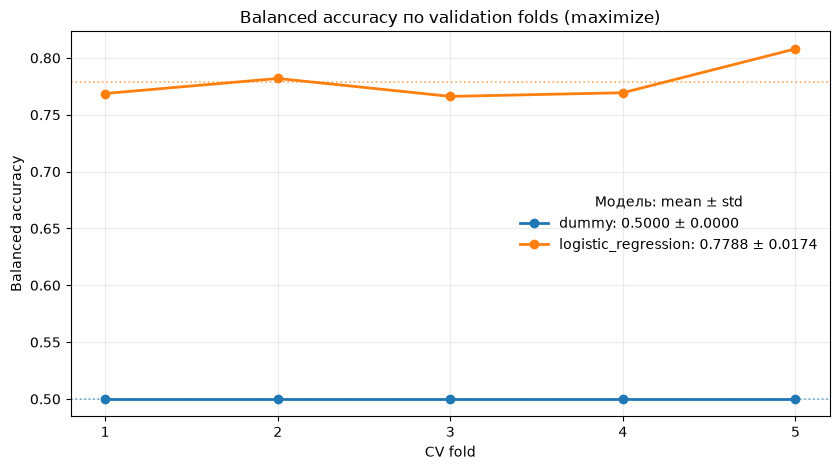

Метрика: Precision


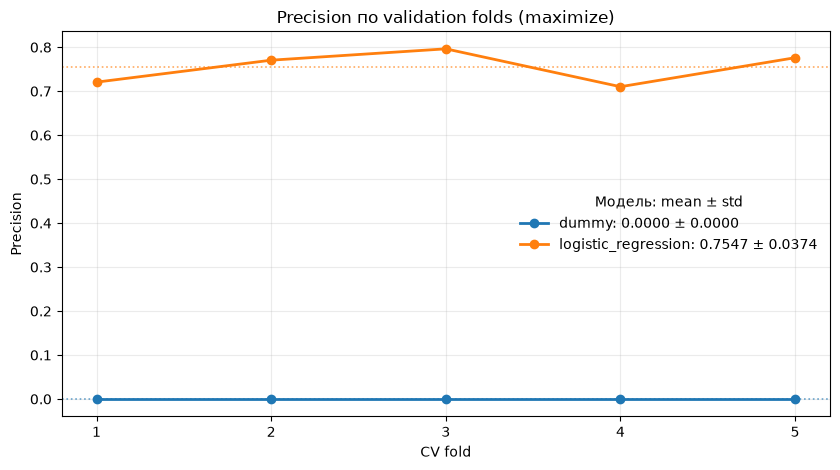

Метрика: Recall


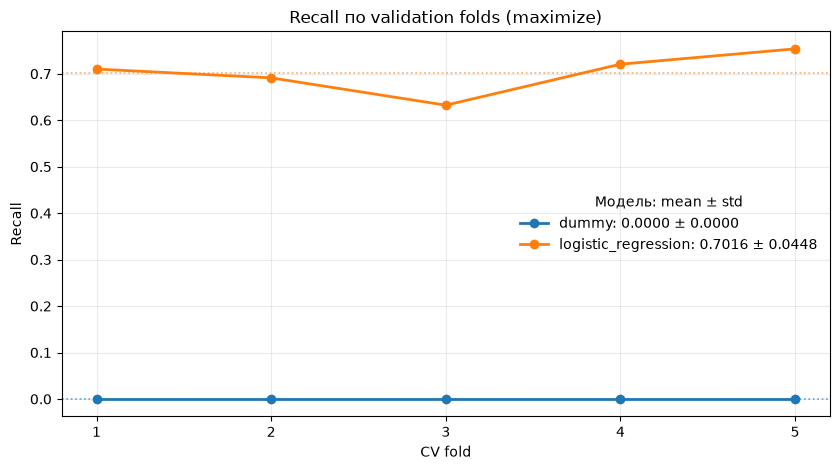

Метрика: F1


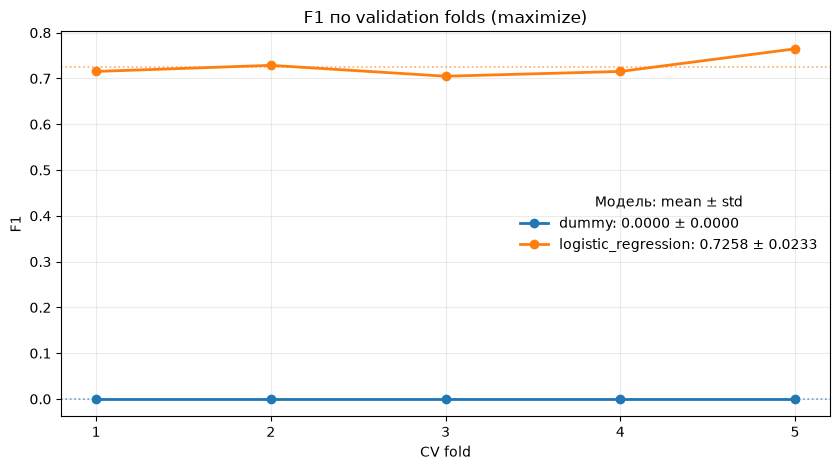

Метрика: ROC-AUC


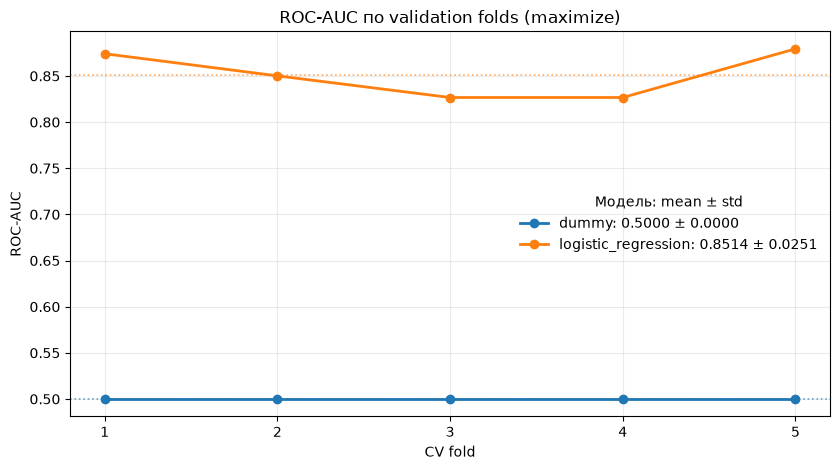

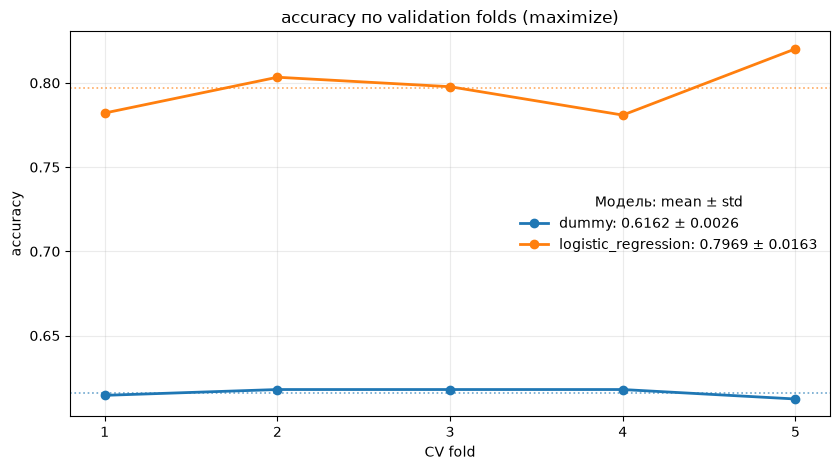

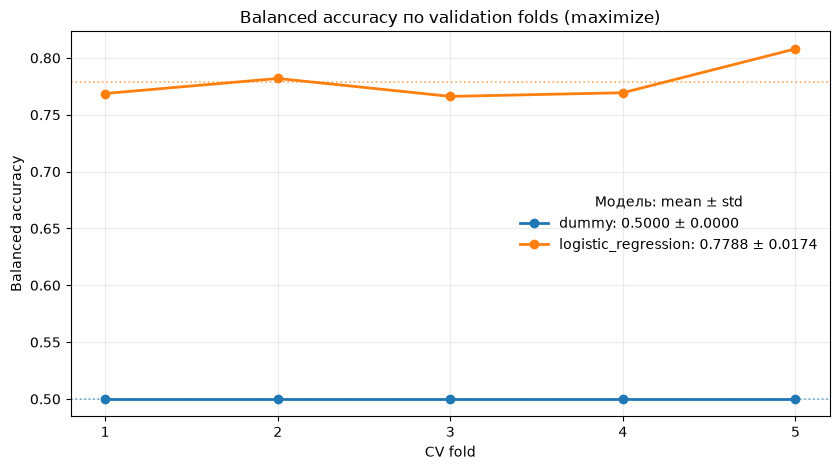

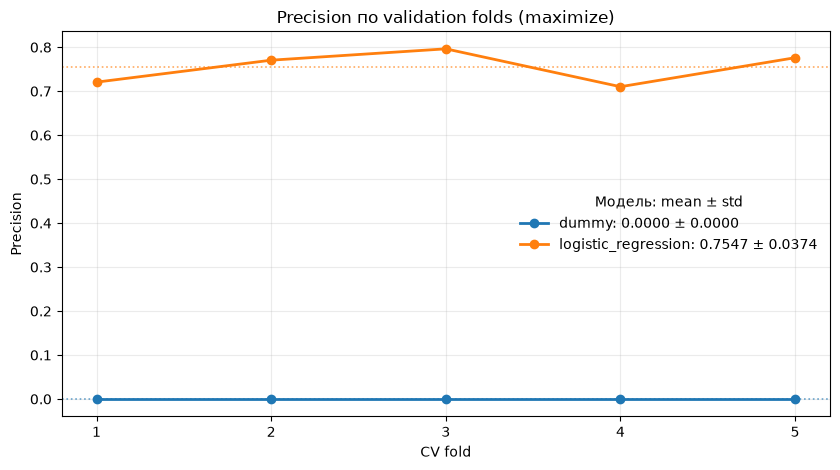

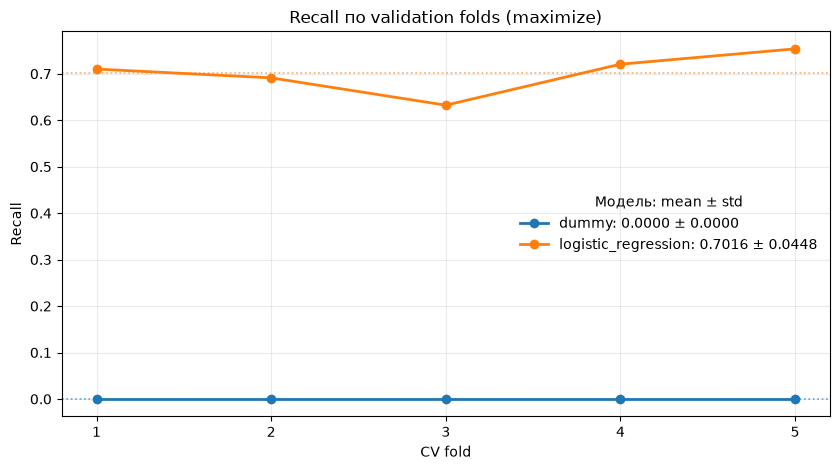

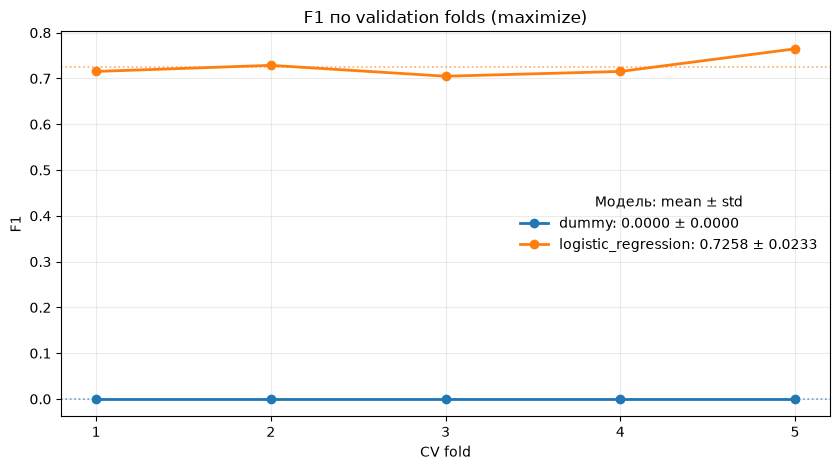

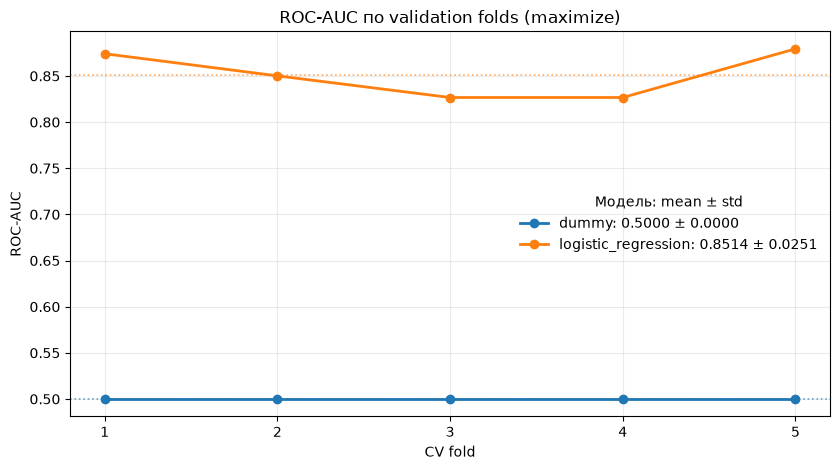

In [14]:
metric_figures = modeling_tools.build_metric_figures(evaluation, scoring_plan)
for metric_key, figure in metric_figures.items():
    print(f"Метрика: {scoring_plan.labels[metric_key]}")
    display(figure)


## 10. Явно сохранить артефакты и обновить отчёты

Запись управляется полями объекта `BASELINE`; основной переключатель — `save_artifacts`.

В `src/ml_project/baseline_config.py` доступны действия:

- `save_artifacts=True` — сохранить CV-таблицы, metadata и PNG каждой метрики;
- `save_metric_figures=True` — сохранить по одному графику на каждую configured metric;
- `save_final_model=True` — дополнительно fit на всём train и сохранить `model.joblib`;
- `sync_experiment_note=True` — создать/обновить карточку `experiment_note`, встроить графики и Markdown-таблицы;
- `sync_docs=True` — обновить auto-блоки в Validation, Features, Experiments и README;
- `allow_overwrite=True` — безопасно повторить тот же run: заменяются только известные сгенерированные файлы, ручные файлы сохраняются.

> [!warning] Новый смысл эксперимента — новый `run_name` и новая карточка. `allow_overwrite=True` предназначен для повторного запуска той же конфигурации, а не для стирания истории разных экспериментов.

После изменения конфига повторно запустите ячейку **1** и все ячейки ниже неё.


In [15]:
saved_run = None
write_requested = settings.save_artifacts or settings.save_final_model

if write_requested:
    saved_run = modeling_tools.save_baseline_run(
        PROJECT_ROOT, settings, evaluation, feature_plan, scoring_plan,
        dataset_version=dataset_version, cv_description=cv_description,
        final_pipeline=models[simple_model_name], data=prepared,
        metric_figures=metric_figures,
    )
    print("Артефакты:", saved_run.run_dir.relative_to(PROJECT_ROOT))
    print("CV folds:", saved_run.fold_scores_path.name)
    print("CV summary:", saved_run.summary_path.name)
    print("Metadata:", saved_run.metadata_path.name)
    for metric_key, figure_path in (saved_run.metric_figure_paths or {}).items():
        print(f"График {scoring_plan.labels[metric_key]}:", figure_path.name)
    if saved_run.model_path is not None:
        print("Final model:", saved_run.model_path.name)
else:
    print("save_artifacts=False и save_final_model=False — файлы не записаны.")

if settings.sync_experiment_note:
    if saved_run is None:
        print("sync_experiment_note пропущен: сначала включите save_artifacts.")
    else:
        updated_experiment = modeling_tools.sync_baseline_experiment_note(
            PROJECT_ROOT, settings, evaluation, scoring_plan, saved_run,
            dataset_version=dataset_version[:12] + "…",
            cv_description=cv_description, model_name=simple_model_name,
        )
        print("Обновлена карточка:", settings.experiment_note, updated_experiment)

if settings.sync_docs:
    experiment_note = (
        settings.experiment_note
        if (PROJECT_ROOT / settings.experiment_note).exists() else None
    )
    updated = modeling_tools.sync_baseline_docs(
        PROJECT_ROOT, evaluation, scoring_plan,
        dataset_version=dataset_version[:12] + "…",
        cv_description=cv_description, model_name=simple_model_name,
        experiment_note=experiment_note,
        settings=settings, feature_plan=feature_plan,
        prepared_data=prepared, saved_run=saved_run,
    )
    print("Обновлены auto-блоки:", updated)
else:
    print("sync_docs=False — stage docs не изменены.")


Артефакты: artifacts\baseline\baseline_v1
CV folds: cv_fold_scores.csv
CV summary: cv_summary.csv
Metadata: metadata.json
График accuracy: metric-primary-accuracy.png
График Balanced accuracy: metric-secondary_1-balanced-accuracy.png
График Precision: metric-secondary_2-precision.png
График Recall: metric-secondary_3-recall.png
График F1: metric-secondary_4-f1.png
График ROC-AUC: metric-secondary_5-roc-auc.png
Обновлена карточка: experiments\EXP-001 Baseline.md ['baseline-experiment-report']
Обновлены auto-блоки: {'README.md': ['key-results'], 'docs/03_validation.md': ['secondary-metrics', 'baseline-results', 'validation-protocol', 'reproducibility'], 'docs/04_features.md': ['model-ready-contract', 'feature-registry', 'preprocessing-contract'], 'docs/05_experiments.md': ['current-baseline', 'best-measured-result'], 'experiments/_index.md': ['experiment-registry']}


## 11. После baseline

1. Откройте автоматически созданную карточку из `EXPERIMENT_NOTE`: там уже встроены все графики, сводки и значения по folds.
2. Проверьте сводки в `docs/03_validation.md` и `docs/05_experiments.md`.
3. Запишите активный preprocessing и исключения в `docs/04_features.md`.
4. Только затем создавайте одну проверяемую гипотезу и меняйте один основной фактор.
5. Inference/submission выполняйте отдельным явным шагом после выбора модели; этот notebook намеренно не использует test для оценки.

### Как масштабировать

- **Сильнее tabular model:** передайте любой sklearn-совместимый estimator в `build_model_pipeline`.
- **Новый preprocessing:** добавьте transformer в reusable-модуль, а не функцию внутри notebook.
- **Text/image/deep learning:** сохраните контракт split, metric, artifact metadata и сравнение с этим baseline, заменив только data/model adapter.
- **Tracker/MLflow:** логируйте те же `run_name`, dataset hash, CV protocol, config и metrics — notebook уже формирует эти сущности отдельно.
